# Exporatory Data Analysis (EDA)

## Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

%matplotlib inline

pd.options.display.max_columns=None

In [6]:
# Creating a seed value to reproduce same results.
SEED = 42


## Import data

In [7]:
from sklearn.datasets import load_breast_cancer
breast_cancer_data = load_breast_cancer()


In [8]:
breast_cancer_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [9]:
breast_cancer_data['feature_names']

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

## Create dataframe

In [10]:
df = pd.DataFrame(data=breast_cancer_data['data'], columns=breast_cancer_data['feature_names'])

# Adding a target set
df['target'] = breast_cancer_data.target

# df.head().T
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Dimension data

In [11]:
print(f'Size of the dataframes: {df.size}')
print(f'Shape of the dataframes: {df.shape}')
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Size of the dataframes: 17639
Shape of the dataframes: (569, 31)
Number of rows: 569
Number of columns: 31


In [12]:
# Two ways to do the same result
print(f'\nNumber of null values:\n{df.isna().sum()}')
print(f'\nNumber of null values:\n{df.isnull().mean().sort_values(ascending=False)}')


Number of null values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Number of null values:
mean radius                0.0
mean text

In [13]:
print(f'\nData Types:\n{df.dtypes}')


Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

In [14]:
print(f'Count values of target variable\n {df["target"].value_counts()}')

Count values of target variable
 target
1    357
0    212
Name: count, dtype: int64


## Map target variable

In [15]:
df['target_classifier'] = df['target'].map({0: 'malignant', 1: 'benign'})
# df.head()

## Statistical Analysis

In [16]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [17]:
display(df.groupby('target_classifier').describe().reset_index())

target_classifier mean radius                                               \
                          count       mean       std     min     25%     50%   
0            benign       357.0  12.146524  1.780512   6.981  11.080  12.200   
1         malignant       212.0  17.462830  3.203971  10.950  15.075  17.325   

                mean texture                                              \
     75%    max        count       mean       std    min      25%    50%   
0  13.37  17.85        357.0  17.914762  3.995125   9.71  15.1500  17.39   
1  19.59  28.11        212.0  21.604906  3.779470  10.38  19.3275  21.46   

                 mean perimeter                                                \
      75%    max          count        mean        std    min     25%     50%   
0  19.760  33.81          357.0   78.075406  11.807438  43.79  70.870   78.18   
1  23.765  39.28          212.0  115.365377  21.854653  71.90  98.745  114.20   

                  mean area                                               \
       75%    max     count        mean         std    min    25%    50%   
0   86.100  114.6     357.0  462.790196  134.287118  143.5  378.2  458.4   
1  129.925  188.5     212.0  978.376415  367.937978  361.6  705.3  932.0   

                   mean smoothness                                        \
       75%     max           count      mean       std      min      25%   
0   551.10   992.1           357.0  0.092478  0.013446  0.05263  0.08306   
1  1203.75  2501.0           212.0  0.102898  0.012608  0.07371  0.09401   

                             mean compactness                               \
       50%       75%     max            count      mean       std      min   
0  0.09076  0.100700  0.1634            357.0  0.080085  0.033750  0.01938   
1  0.10220  0.110925  0.1447            212.0  0.145188  0.053987  0.04605   

                                     mean concavity                      \
       25%      50%      75%     max          count      mean       std   
0  0.05562  0.07529  0.09755  0.2239          357.0  0.046058  0.043442   
1  0.10960  0.13235  0.17240  0.3454          212.0  0.160775  0.075019   

                                               mean concave points            \
       min       25%      50%      75%     max               count      mean   
0  0.00000  0.020310  0.03709  0.05999  0.4108               357.0  0.025717   
1  0.02398  0.109525  0.15135  0.20305  0.4268               212.0  0.087990   

                                                          mean symmetry  \
        std      min      25%      50%       75%      max         count   
0  0.015909  0.00000  0.01502  0.02344  0.032510  0.08534         357.0   
1  0.034374  0.02031  0.06462  0.08628  0.103175  0.20120         212.0   

                                                                 \
       mean       std     min      25%     50%      75%     max   
0  0.174186  0.024807  0.1060  0.15800  0.1714  0.18900  0.2743   
1  0.192909  0.027638  0.1308  0.17405  0.1899  0.20985  0.3040   

  mean fractal dimension                                                   \
                   count      mean       std      min       25%       50%   
0                  357.0  0.062867  0.006747  0.05185  0.058530  0.061540   
1                  212.0  0.062680  0.007573  0.04996  0.056598  0.061575   

                     radius error                                        \
        75%      max        count      mean       std     min       25%   
0  0.065760  0.09575        357.0  0.284082  0.112570  0.1115  0.207300   
1  0.067075  0.09744        212.0  0.609083  0.345039  0.1938  0.390375   

                          texture error                                        \
      50%     75%     max         count      mean       std     min       25%   
0  0.2575  0.3416  0.8811         357.0  1.220380  0.589180  0.3602  0.795900   
1  0.5472  0.7573  2.8730         212.0  1.210915  0.483178  0.3621  0.892825   

 

## Charts

In [18]:
variables= breast_cancer_data.feature_names
variables.size

30

### Boxplot

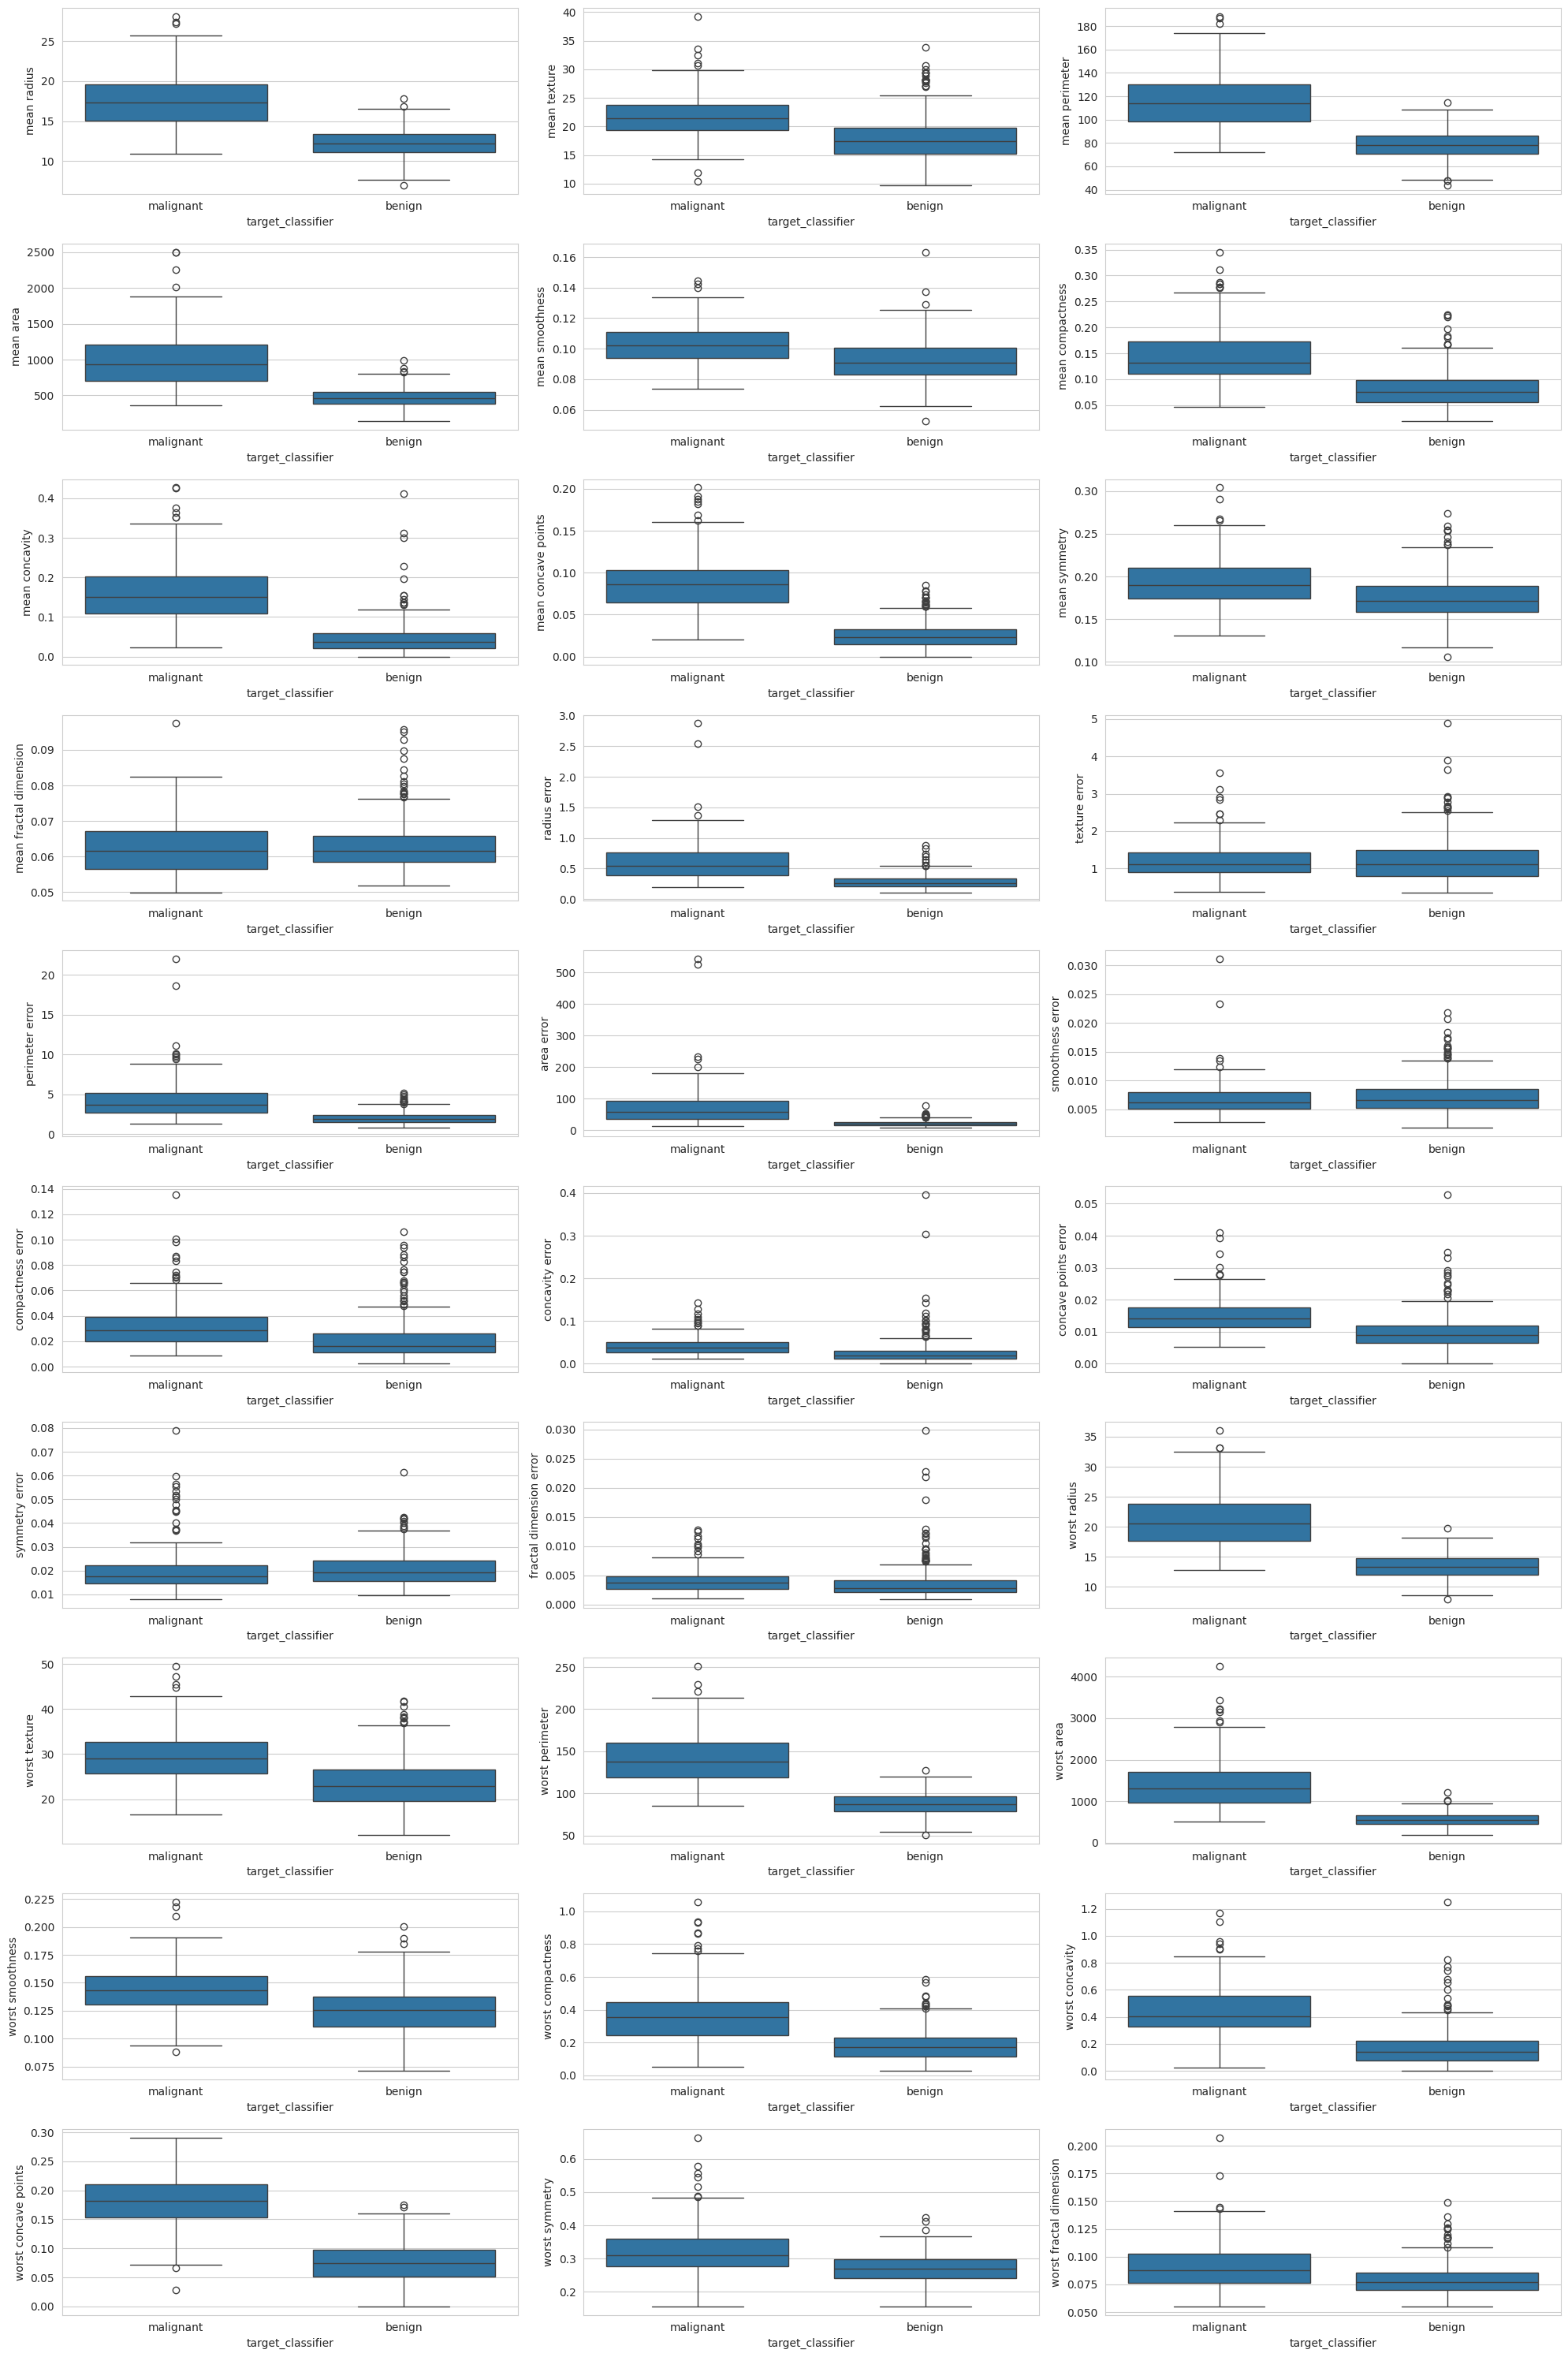

In [19]:
plt.figure(figsize=(20, 30))
sns.set_style('whitegrid')
for i, c in enumerate(variables, 1):
  plt.subplot(10, 3, i) # 10 lines with each 3 charts (30 variables = 30/10 = 3)
  sns.boxplot(data=df, x='target_classifier', y=c) # 'c' as the column name for the y-axis
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Histogram

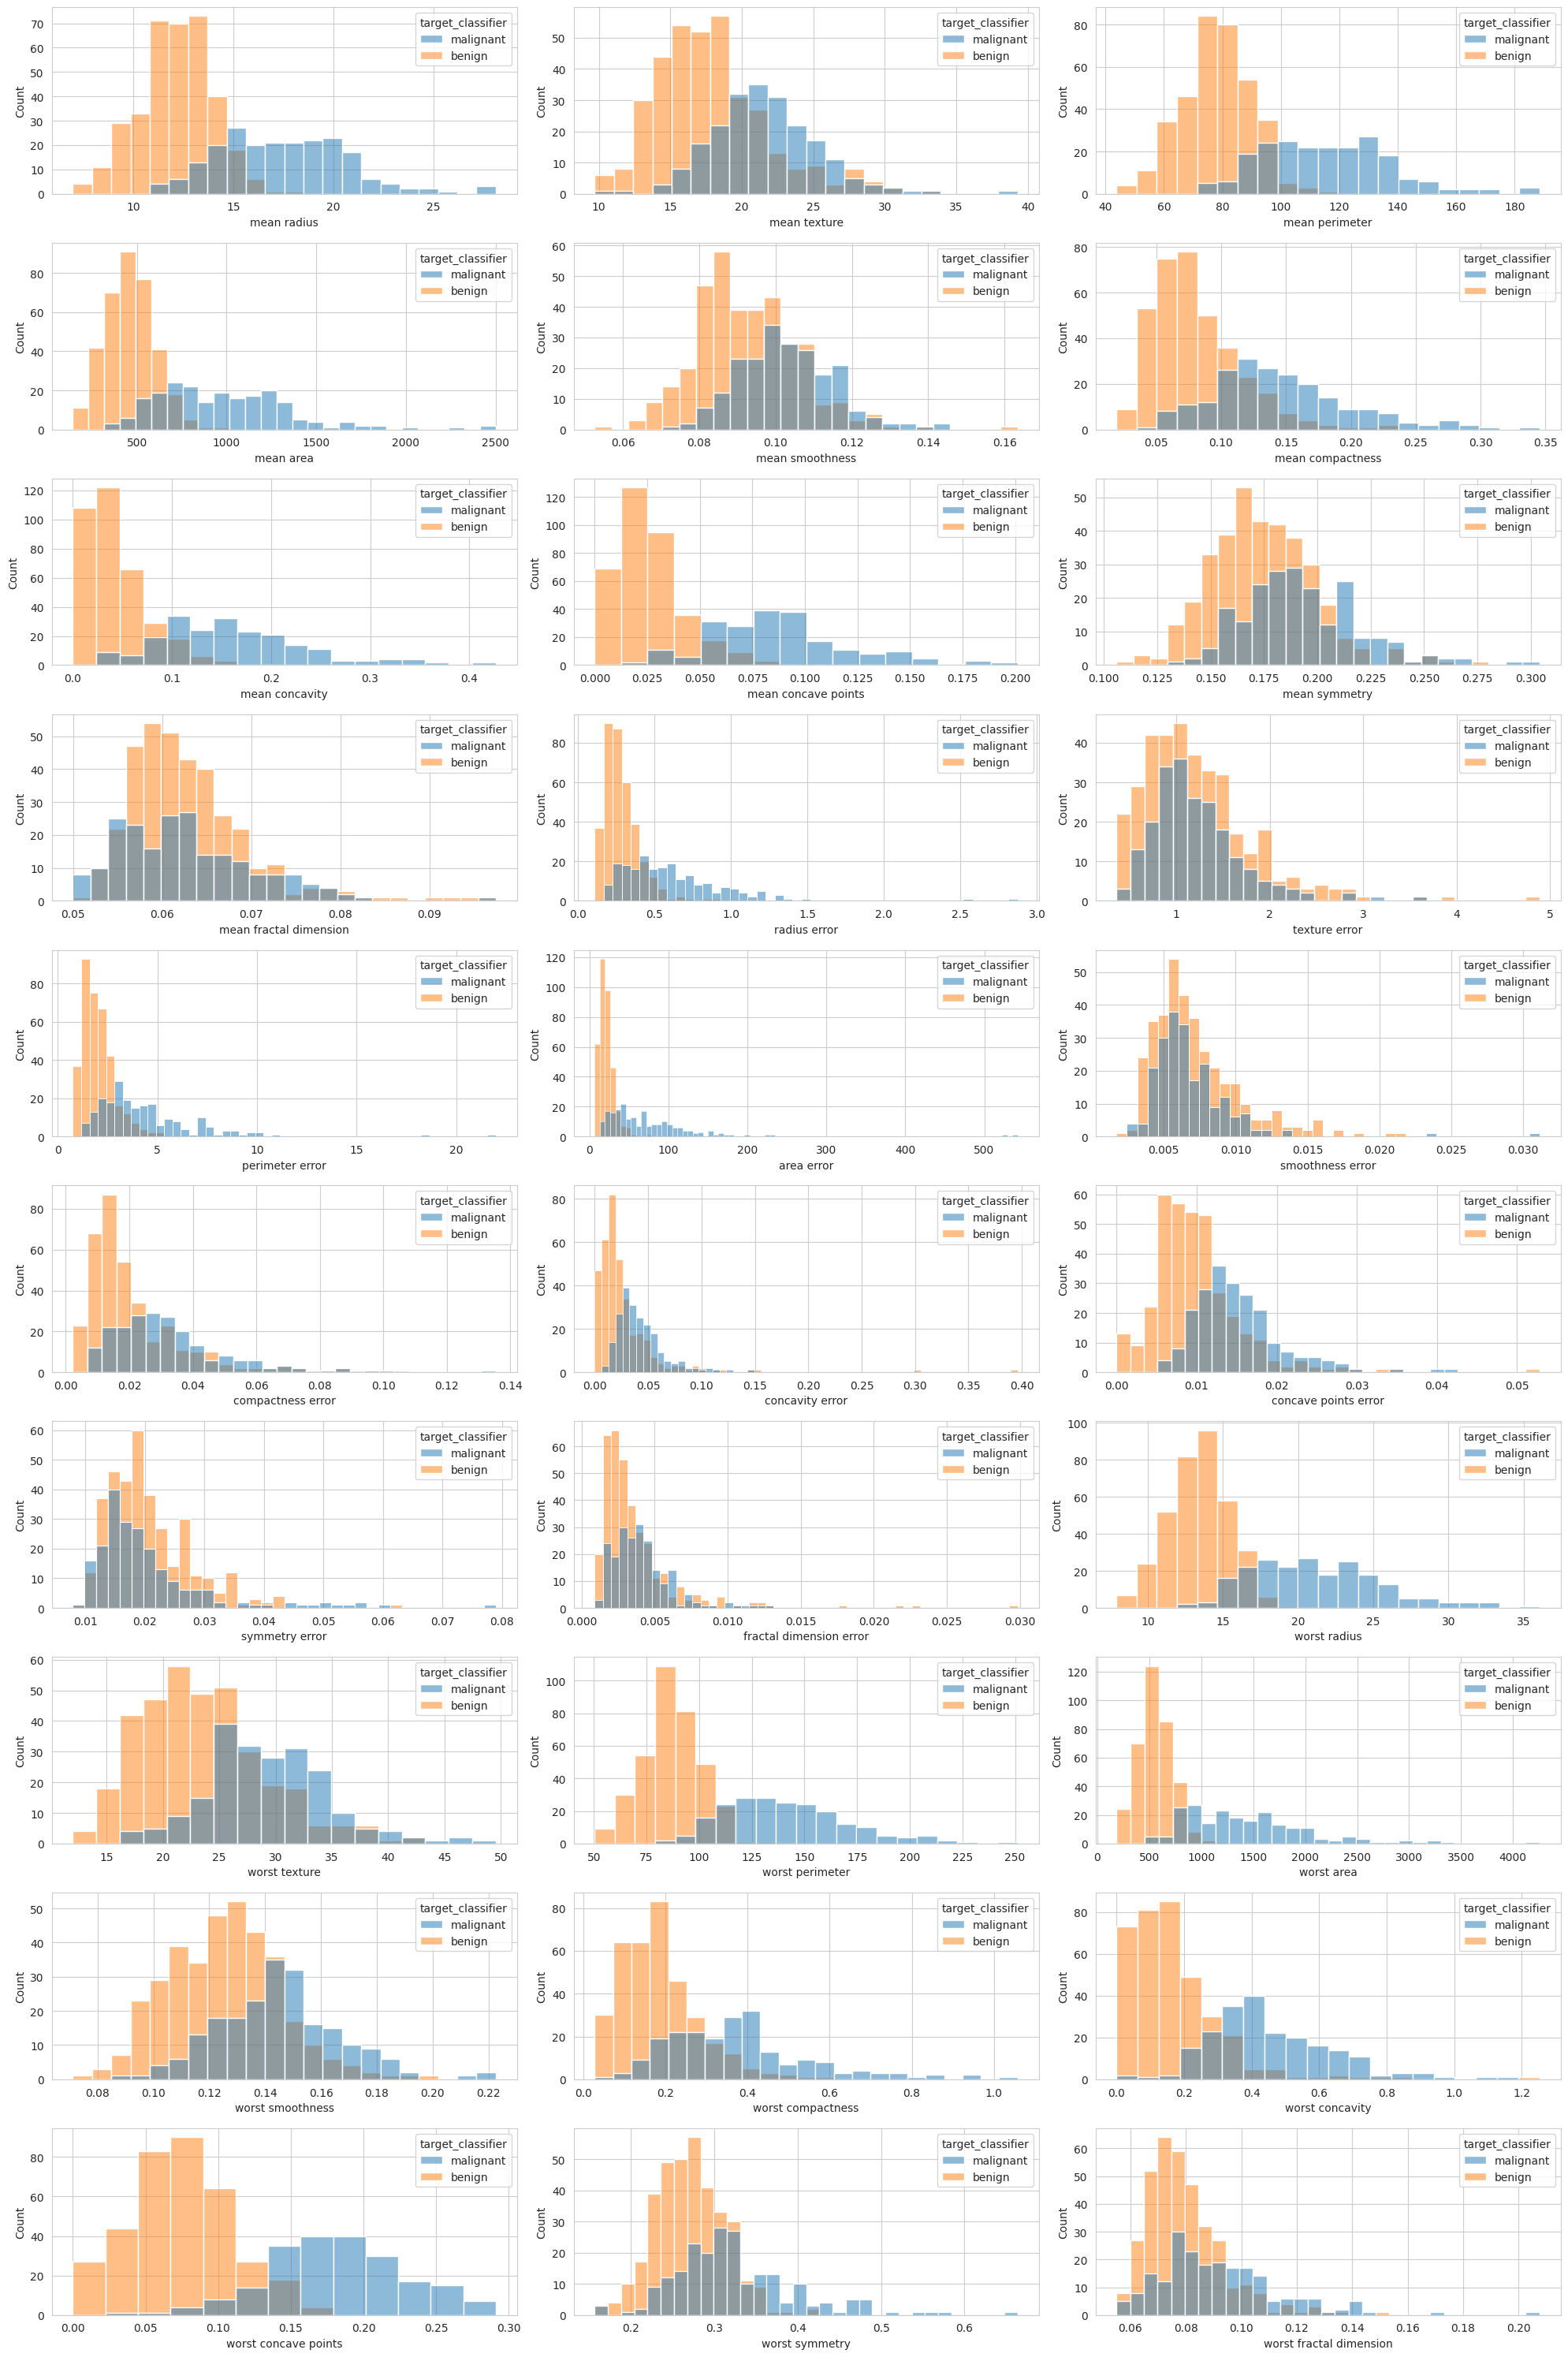

In [20]:
plt.figure(figsize=(20, 30))
sns.set_style('whitegrid')
for i, c in enumerate(variables, 1):
  plt.subplot(10, 3, i)
  sns.histplot(data=df, x=c, hue='target_classifier')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()



### Correlation matrix

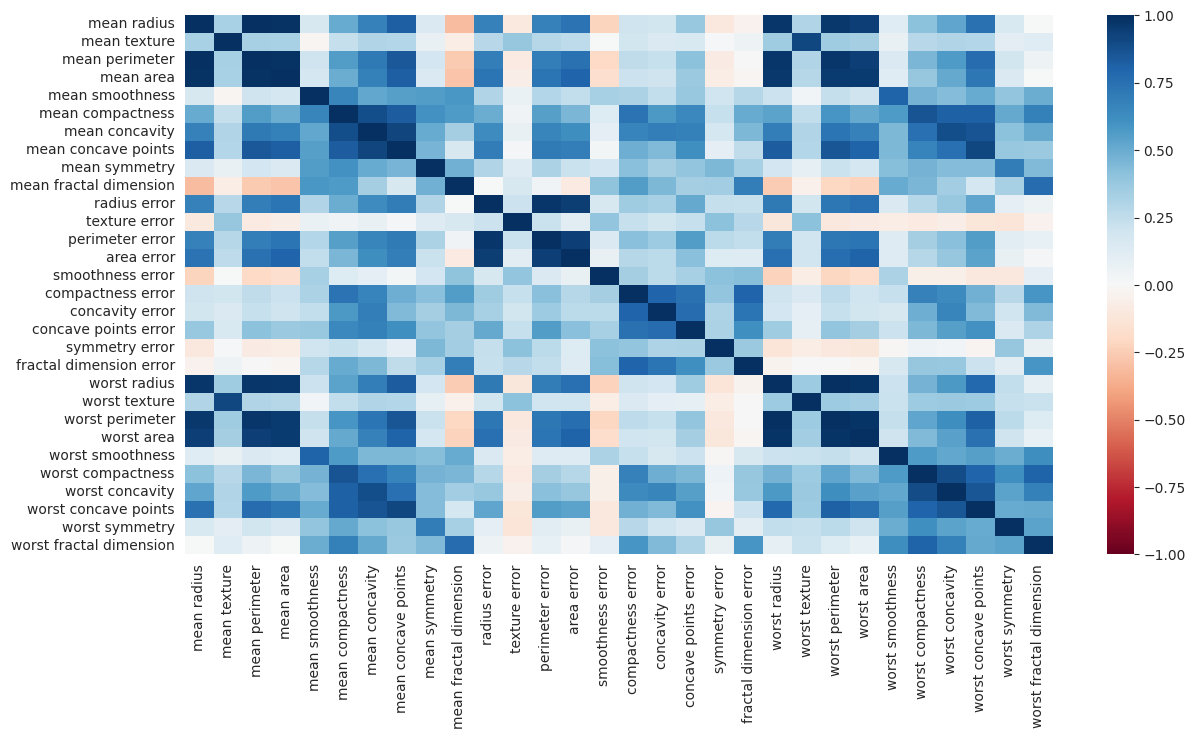

In [21]:
plt.figure(figsize=(14, 7))
sns.heatmap(df[variables].corr(), cmap='RdBu', vmin=-1, vmax=1)
plt.show()

# Modeling